# Entrega 6 — Notebook Final Integrador
**Proyecto:** Brecha de eficiencia en la inversión pública peruana (MEF 2020–2026)
**Curso:** Data Visualization CC0211 · UPC

**Pregunta analítica:** ¿En qué medida la ejecución financiera de las inversiones públicas
refleja el avance real de las obras, y qué sectores o regiones presentan los mayores
cuellos de botella durante el periodo 2020–2026?

Este notebook consolida la Entrega 6:

1. **Resumen del pipeline** — Bronze → Silver → Gold → Star Schema
2. **PCA** — componente avanzado: qué variables pesan más en cada componente
3. **Interpretación** — qué significan PC1 y PC2 para la pregunta analítica
4. **Validación final del esquema estrella** — integridad referencial y totales


In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path

ROOT = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
GOLD = ROOT / "data" / "gold"

plt.rcParams.update({"figure.dpi": 110, "axes.spines.top": False, "axes.spines.right": False})
pd.set_option("display.float_format", lambda x: f"{x:,.2f}")

## Sección 1 — Resumen del pipeline (Bronze → Silver → Gold → Star Schema)

El proyecto sigue una arquitectura **Medallion** reproducible en Python/Polars
(`run_pipeline.py` orquesta los pasos):

| Paso | Script | Qué hace |
|---|---|---|
| 0 | `00_download_data.py` | Descarga los 3 CSV del portal de Datos Abiertos del MEF (detalle de inversiones, Formato 12-B, cierre de inversiones) |
| 1 | `01_bronze.py` | CSV crudo → Parquet, sin lógica de negocio (trazabilidad del dato original) |
| 2 | `02_eda_preliminary.py` | Perfilado: nulos, cardinalidad, solapamiento de llaves entre fuentes |
| 3 | `03_silver.py` | Limpieza, tipado, merge de las 3 fuentes y clasificación NLP de problemas |
| 4 | `04_gold.py` | Métricas de negocio: **BRECHA**, DIAS_SIN_REPORTE, DIAS_ARRANQUE, flags de calidad |
| 5 | `06_star_schema.py` | Esquema estrella: `fact_inversiones` + 5 dimensiones con llaves sustitutas, semáforos y segmentos para Tableau |
| 6 | `07_pca.py` | Componente avanzado: PCA con scikit-learn → `pca_proyectos.csv` |

**Reglas de negocio clave aplicadas en Gold:**
- Proyectos `CLOSED` sin avance físico reportado se asumen al 100 %.
- Avances > 100 % se tratan como error de digitación y se limitan a 100.
- `BRECHA = AVANCE_EJECUCION − AVANCE_FISICO` (positiva ⇒ se gasta más rápido de lo que se construye).


In [2]:
# Tablas del esquema estrella exportadas para Tableau
tablas = ["fact_inversiones", "dim_proyecto", "dim_ubicacion",
          "dim_institucion", "dim_estructura", "dim_tiempo", "pca_proyectos"]
resumen = []
for t in tablas:
    df_t = pd.read_csv(GOLD / f"{t}.csv", low_memory=False)
    resumen.append({"tabla": t, "filas": len(df_t), "columnas": df_t.shape[1]})
pd.DataFrame(resumen)

,tabla,filas,columnas
0,fact_inversiones,291453,26
1,dim_proyecto,291453,13
2,dim_ubicacion,2108,7
3,dim_institucion,2127,4
4,dim_estructura,34,4
5,dim_tiempo,14976,6
6,pca_proyectos,291453,6


In [3]:
fact = pd.read_csv(GOLD / "fact_inversiones.csv", low_memory=False)
dim_inst = pd.read_csv(GOLD / "dim_institucion.csv")
fact = fact.merge(dim_inst[["SK_Institucion", "SECTOR"]], on="SK_Institucion", how="left")

print(f"Universo: {len(fact):,} proyectos de inversión pública")
print(f"Costo actualizado total de la cartera: S/ {fact.COSTO_ACTUALIZADO.sum()/1e6:,.0f} millones")
print()
print("Distribución LIFECYCLE:")
print(fact.LIFECYCLE.value_counts().to_string())
print()
print("Distribución SEMAFORO_BRECHA:")
print(fact.SEMAFORO_BRECHA.value_counts().to_string())

Universo: 291,453 proyectos de inversión pública
Costo actualizado total de la cartera: S/ 1,541,483 millones

Distribución LIFECYCLE:
LIFECYCLE
ACTIVE    183692
CLOSED    107761

Distribución SEMAFORO_BRECHA:
SEMAFORO_BRECHA
SIN DATO    187668
NORMAL      103509
ALERTA         256
CRITICO         20


## Sección 2 — PCA: qué variables pesan más en cada componente

El componente avanzado del proyecto es un **PCA (Análisis de Componentes Principales)**
sobre las 6 métricas numéricas centrales:
`BRECHA`, `AVANCE_FISICO`, `AVANCE_EJECUCION`, `DIAS_SIN_REPORTE`, `DIAS_ARRANQUE`,
`COSTO_ACTUALIZADO`.

**Decisiones metodológicas** (implementadas en `scripts/07_pca.py`):
- **Imputación por mediana**: robusta frente a la fuerte asimetría del costo y de las
  variables de días; la media estaría sesgada por megaproyectos y colas largas.
- **Estandarización z-score**: las variables mezclan unidades (pp, días, soles);
  sin escalar, `COSTO_ACTUALIZADO` dominaría la varianza total.
- **2 componentes**: suficientes para proyectar la cartera en un scatter interpretable
  en Tableau, que es el objetivo del componente avanzado.


In [4]:
from sklearn.decomposition import PCA
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler

FEATURES = ["BRECHA", "AVANCE_FISICO", "AVANCE_EJECUCION",
            "DIAS_SIN_REPORTE", "DIAS_ARRANQUE", "COSTO_ACTUALIZADO"]

print("Nulos por variable (antes de imputar):")
print((fact[FEATURES].isna().mean() * 100).round(1).astype(str) + " %")

imputer = SimpleImputer(strategy="median")
X = imputer.fit_transform(fact[FEATURES])
X_std = StandardScaler().fit_transform(X)

pca = PCA(n_components=2, random_state=42)
Z = pca.fit_transform(X_std)

var_exp = pca.explained_variance_ratio_ * 100
print(f"\nVarianza explicada: PC1 = {var_exp[0]:.2f} %  |  PC2 = {var_exp[1]:.2f} %"
      f"  |  acumulada = {var_exp.sum():.2f} %")

loadings = pd.DataFrame(pca.components_.T, index=FEATURES, columns=["PC1", "PC2"])
loadings.round(3)

Nulos por variable (antes de imputar):
BRECHA               64.4 %
AVANCE_FISICO        19.3 %
AVANCE_EJECUCION     47.1 %
DIAS_SIN_REPORTE     62.8 %
DIAS_ARRANQUE        53.0 %
COSTO_ACTUALIZADO     0.0 %
dtype: str

Varianza explicada: PC1 = 24.99 %  |  PC2 = 19.86 %  |  acumulada = 44.85 %


,PC1,PC2
BRECHA,0.31,0.70
AVANCE_FISICO,0.21,-0.65
AVANCE_EJECUCION,0.69,0.11
DIAS_SIN_REPORTE,0.61,-0.25
DIAS_ARRANQUE,-0.07,0.10
COSTO_ACTUALIZADO,-0.04,0.03


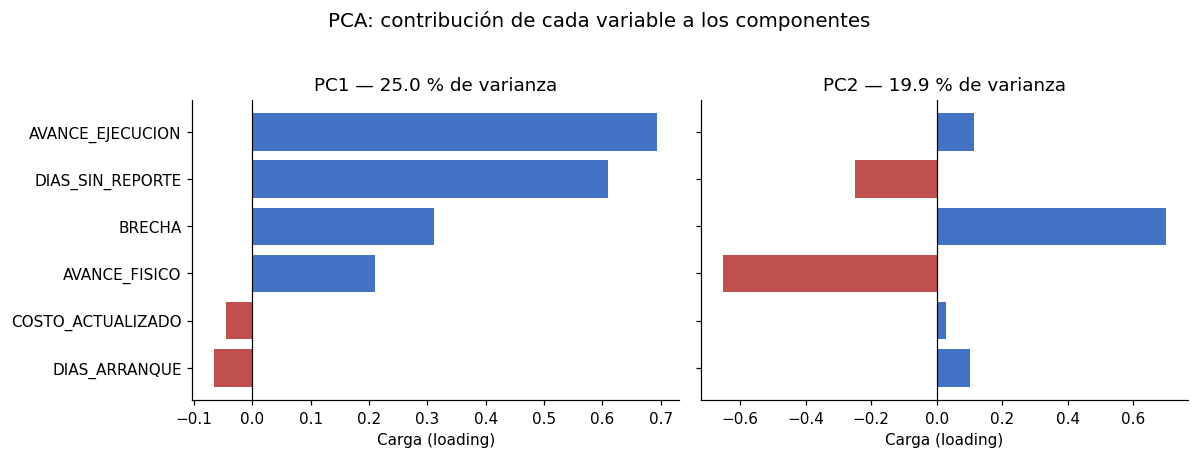

In [5]:
# Cargas de cada variable en PC1 y PC2
fig, axes = plt.subplots(1, 2, figsize=(11, 4), sharey=True)
for ax, pc in zip(axes, ["PC1", "PC2"]):
    vals = loadings[pc].sort_values()
    colors = ["#c0504d" if v < 0 else "#4472c4" for v in vals]
    ax.barh(vals.index, vals.values, color=colors)
    ax.axvline(0, color="black", lw=0.8)
    ax.set_title(f"{pc} — {var_exp[0 if pc=='PC1' else 1]:.1f} % de varianza")
    ax.set_xlabel("Carga (loading)")
fig.suptitle("PCA: contribución de cada variable a los componentes", y=1.03, fontsize=13)
plt.tight_layout()
plt.show()

**Lectura de las cargas:**

- **PC1** está dominado por `AVANCE_EJECUCION` (+0.69) y `DIAS_SIN_REPORTE` (+0.61),
  con aporte de `BRECHA` (+0.31). Es un eje de **madurez financiera y antigüedad del
  reporte**: proyectos con alta ejecución acumulada y reportes antiguos puntúan alto.
- **PC2** contrapone `BRECHA` (+0.70) contra `AVANCE_FISICO` (−0.65). Es exactamente el
  eje de la pregunta analítica: **desalineación financiero-física**. Valores altos ⇒
  mucha plata devengada y poca obra.
- `COSTO_ACTUALIZADO` y `DIAS_ARRANQUE` casi no pesan en ninguno de los dos componentes:
  la envergadura presupuestal y la demora de arranque son ortogonales al problema de
  eficiencia — un hallazgo en sí mismo.


## Sección 3 — Interpretación: qué significan PC1 y PC2 para la pregunta analítica

Proyectamos la cartera en el plano (PC1, PC2) coloreando por `SEMAFORO_BRECHA`
(la segmentación central del dashboard) para verificar que el PCA **separa** los
grupos de interés.


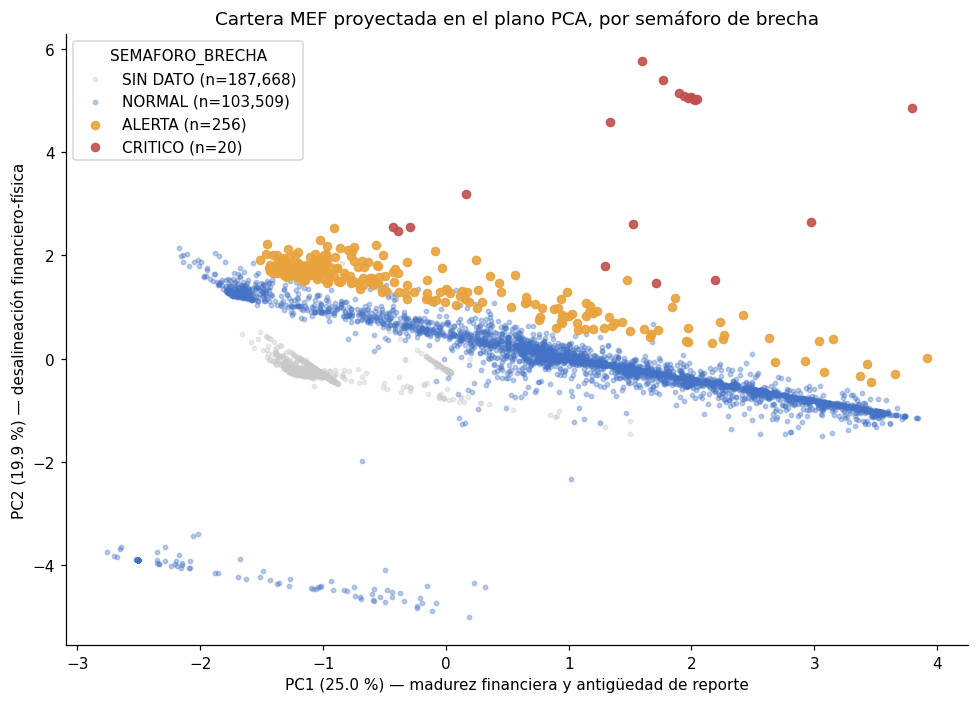

In [6]:
out = fact[["SK_Proyecto", "SEMAFORO_BRECHA", "LIFECYCLE", "SECTOR"]].copy()
out["PC1"], out["PC2"] = Z[:, 0], Z[:, 1]

# Muestra estratificada para el scatter (el CSV completo va a Tableau)
rng = np.random.default_rng(42)
frames = []
for grupo, g in out.groupby("SEMAFORO_BRECHA"):
    n = min(len(g), 4000)
    frames.append(g.sample(n, random_state=42))
muestra = pd.concat(frames)

colores = {"NORMAL": "#4472c4", "ALERTA": "#e8a33d", "CRITICO": "#c0504d", "SIN DATO": "#c8c8c8"}
fig, ax = plt.subplots(figsize=(9, 6.5))
for grupo in ["SIN DATO", "NORMAL", "ALERTA", "CRITICO"]:
    g = muestra[muestra.SEMAFORO_BRECHA == grupo]
    ax.scatter(g.PC1, g.PC2, s=8 if grupo in ("SIN DATO", "NORMAL") else 28,
               alpha=0.35 if grupo in ("SIN DATO", "NORMAL") else 0.9,
               c=colores[grupo], label=f"{grupo} (n={ (out.SEMAFORO_BRECHA==grupo).sum():,})")
ax.set_xlabel(f"PC1 ({var_exp[0]:.1f} %) — madurez financiera y antigüedad de reporte")
ax.set_ylabel(f"PC2 ({var_exp[1]:.1f} %) — desalineación financiero-física")
ax.set_title("Cartera MEF proyectada en el plano PCA, por semáforo de brecha")
ax.legend(title="SEMAFORO_BRECHA", loc="upper left")
plt.tight_layout()
plt.show()

**Interpretación para la pregunta analítica:**

- **PC2 es el eje de riesgo.** Los proyectos `CRITICO` y `ALERTA` se concentran en la
  parte alta del plano (PC2 > 0): alta brecha con poco avance físico. El semáforo —
  construido con reglas de negocio simples — y el PCA — construido solo con la
  estructura estadística de los datos — **coinciden**, lo que valida la segmentación
  del dashboard.
- **PC1 ordena el ciclo de vida.** Hacia la derecha aparecen proyectos con ejecución
  financiera alta y reportes antiguos (típicamente cerrados o por cerrar); hacia la
  izquierda, proyectos jóvenes con poco devengado.
- **Traducción operativa:** el cuadrante **PC1 alto + PC2 alto** es la zona de
  fiscalización prioritaria: proyectos que ya consumieron presupuesto, dejaron de
  reportar y muestran brecha alta. Ese es el filtro que el módulo avanzado aporta
  al dashboard de Tableau (`pca_proyectos.csv`).


In [7]:
# Validación cruzada de la lectura: medias de las variables originales por cuadrante de PC2
out2 = fact[FEATURES + ["SEMAFORO_BRECHA"]].copy()
out2["PC2_alto"] = Z[:, 1] > 1
comp = out2.groupby("PC2_alto")[["BRECHA", "AVANCE_FISICO", "AVANCE_EJECUCION"]].mean().round(1)
comp.index = ["PC2 ≤ 1 (resto de la cartera)", "PC2 > 1 (zona de riesgo)"]
comp

,BRECHA,AVANCE_FISICO,AVANCE_EJECUCION
PC2 ≤ 1 (resto de la cartera),-13.60,93.90,50.50
PC2 > 1 (zona de riesgo),1.80,1.20,11.10


## Sección 4 — Validación final del esquema estrella

Se valida la integridad referencial entre `fact_inversiones` y las dimensiones,
la unicidad de la llave de la fact y la consistencia del export del PCA.


In [8]:
dim_ubi = pd.read_csv(GOLD / "dim_ubicacion.csv")
dim_est = pd.read_csv(GOLD / "dim_estructura.csv")
dim_pro = pd.read_csv(GOLD / "dim_proyecto.csv", low_memory=False)
dim_tie = pd.read_csv(GOLD / "dim_tiempo.csv")
pca_csv = pd.read_csv(GOLD / "pca_proyectos.csv")

checks = []
def check(nombre, cond, detalle=""):
    checks.append({"validación": nombre, "resultado": "OK" if cond else "FALLA", "detalle": detalle})

# 1. Unicidad de la llave de la fact
dup = fact.SK_Proyecto.duplicated().sum()
check("fact: SK_Proyecto único", dup == 0, f"{dup} duplicados")

# 2. Integridad referencial fact -> dimensiones
for sk, dim, col in [("SK_Ubicacion", dim_ubi, "SK_Ubicacion"),
                     ("SK_Institucion", dim_inst, "SK_Institucion"),
                     ("SK_Estructura", dim_est, "SK_Estructura")]:
    huerf = (~fact[sk].dropna().isin(dim[col])).sum()
    check(f"fact.{sk} → dim", huerf == 0, f"{huerf} llaves huérfanas")

# 3. fact -> dim_proyecto por llave natural
huerf_p = (~fact.SK_Proyecto.isin(dim_pro.CODIGO_UNICO)).sum()
check("fact.SK_Proyecto → dim_proyecto", huerf_p == 0, f"{huerf_p} huérfanas")

# 4. Llaves de tiempo (−1 = fecha nula, permitido por diseño)
sk_t = [c for c in fact.columns if c.startswith("SK_Tiempo_")]
validas = set(dim_tie.SK_Tiempo)
malas = sum((~fact[c].isin(validas) & (fact[c] != -1)).sum() for c in sk_t)
check("fact.SK_Tiempo_* → dim_tiempo", malas == 0, f"{malas} fechas fuera de calendario")

# 4b. Unicidad de SK_Tiempo en dim_tiempo (ver hallazgo de QA más abajo)
dup_t = dim_tie.SK_Tiempo.duplicated().sum()
check("dim_tiempo: SK_Tiempo único", dup_t == 0, f"{dup_t:,} SK duplicados")

# 5. Export del PCA cubre toda la fact, 1 a 1
check("pca_proyectos: misma cardinalidad que fact",
      len(pca_csv) == len(fact) and pca_csv.SK_Proyecto.duplicated().sum() == 0,
      f"{len(pca_csv):,} filas")
check("pca_proyectos: PC1/PC2 sin nulos",
      pca_csv[["PC1", "PC2"]].isna().sum().sum() == 0)

# 6. Consistencia de totales fact vs gold master
check("COSTO_ACTUALIZADO sin nulos en fact", fact.COSTO_ACTUALIZADO.isna().sum() == 0)

pd.DataFrame(checks)

,validación,resultado,detalle
0,fact: SK_Proyecto único,OK,0 duplicados
1,fact.SK_Ubicacion → dim,OK,0 llaves huérfanas
2,fact.SK_Institucion → dim,OK,0 llaves huérfanas
3,fact.SK_Estructura → dim,OK,0 llaves huérfanas
4,fact.SK_Proyecto → dim_proyecto,OK,0 huérfanas
5,fact.SK_Tiempo_* → dim_tiempo,OK,0 fechas fuera de calendario
6,dim_tiempo: SK_Tiempo único,OK,0 SK duplicados
7,pca_proyectos: misma cardinalidad que fact,OK,"291,453 filas"
8,pca_proyectos: PC1/PC2 sin nulos,OK,
9,COSTO_ACTUALIZADO sin nulos en fact,OK,


### Hallazgo de QA (detectado y corregido): overflow de Int8 en las llaves de tiempo

La primera ejecución de esta validación **falló** en las llaves de tiempo, y no era
un falso positivo. En polars 1.40.1, `dt.month()` devuelve `Int8`; la fórmula
original `year*10000 + month*100 + day` de `06_star_schema.py` aplicaba el
`.cast(pl.Int64)` **después** de la suma, por lo que `month*100` desbordaba para
todo mes ≥ 2 (ej.: `12*100 = 1200 → −80` en Int8). Así, `2020-12-31` producía el
SK `20199951` en lugar de `20201231`; solo las fechas de **enero** generaban SK
correctos. El impacto medido antes del fix: 4,680 SK duplicados en `dim_tiempo`
(35.6 %) y joins fact → dim_tiempo inflados de 291,453 a 514,634 filas.

**Corrección aplicada** en `fecha_a_sk()` y `build_dim_tiempo()`: castear cada
componente a Int64 *antes* de multiplicar
(`dt.year().cast(pl.Int64)*10000 + dt.month().cast(pl.Int64)*100 + dt.day().cast(pl.Int64)`).
Adicionalmente, el calendario se extendió de 2035 a 2040 porque existen proyectos
con fin de ejecución planificado en 2036. La celda siguiente verifica el estado
posterior al fix.


In [9]:
# Verificación post-fix del bug de SK_Tiempo
ejemplo = dim_tie[dim_tie.FECHA.isin(["2020-01-15", "2020-08-10", "2020-12-31"])]
print("Ejemplos dim_tiempo (SK esperado = YYYYMMDD):")
print(ejemplo[["FECHA", "SK_Tiempo"]].to_string(index=False))

dup_t = dim_tie.SK_Tiempo.duplicated().sum()
print(f"\nSK_Tiempo duplicados en dim_tiempo : {dup_t:,} de {len(dim_tie):,}")

infl = fact[["SK_Tiempo_FECHA_REGISTRO"]].merge(
    dim_tie[["SK_Tiempo"]], left_on="SK_Tiempo_FECHA_REGISTRO",
    right_on="SK_Tiempo", how="left")
print(f"Join fact → dim_tiempo por SK      : {len(fact):,} filas → {len(infl):,}")
assert dup_t == 0 and len(infl) == len(fact), "El bug de SK_Tiempo sigue presente"
print("\nOK: llaves de tiempo únicas y join sin inflación.")

Ejemplos dim_tiempo (SK esperado = YYYYMMDD):
     FECHA  SK_Tiempo
2020-01-15   20200115
2020-08-10   20200810
2020-12-31   20201231

SK_Tiempo duplicados en dim_tiempo : 0 de 14,976
Join fact → dim_tiempo por SK      : 291,453 filas → 291,453

OK: llaves de tiempo únicas y join sin inflación.


**Lección para la defensa:** el bug fue detectado por la propia celda de
validación de integridad referencial de este notebook, se diagnosticó hasta la
causa raíz, se cuantificó su impacto y se corrigió regenerando el esquema estrella
completo. Es la diferencia entre un pipeline auditado y uno que solo parece limpio.


In [10]:
print("Resumen ejecutivo de validación")
print("=" * 45)
print(f"Proyectos en la fact              : {len(fact):,}")
print(f"Proyectos con BRECHA calculable   : {fact.BRECHA.notna().sum():,} "
      f"({fact.BRECHA.notna().mean()*100:.1f} %)")
print(f"Proyectos CRITICO                 : {(fact.SEMAFORO_BRECHA=='CRITICO').sum():,}")
print(f"Proyectos ALERTA                  : {(fact.SEMAFORO_BRECHA=='ALERTA').sum():,}")
print(f"Varianza explicada PC1+PC2        : {var_exp.sum():.1f} %")
print()
print("Esquema estrella íntegro: sin llaves huérfanas, duplicados ni SK de tiempo")
print("fuera de calendario (bug de overflow Int8 detectado en QA y corregido).")
print("pca_proyectos.csv listo para conectarse a Tableau por SK_Proyecto.")

Resumen ejecutivo de validación
Proyectos en la fact              : 291,453
Proyectos con BRECHA calculable   : 103,785 (35.6 %)
Proyectos CRITICO                 : 20
Proyectos ALERTA                  : 256
Varianza explicada PC1+PC2        : 44.8 %

Esquema estrella íntegro: sin llaves huérfanas, duplicados ni SK de tiempo
fuera de calendario (bug de overflow Int8 detectado en QA y corregido).
pca_proyectos.csv listo para conectarse a Tableau por SK_Proyecto.


---
**Conclusión del notebook:** el pipeline Bronze→Silver→Gold→Star Schema produce un
esquema estrella íntegro y reproducible; el PCA confirma estadísticamente que la
desalineación financiero-física (PC2) es una dimensión real y separable de la cartera,
y `pca_proyectos.csv` traslada ese hallazgo al dashboard de Tableau como módulo avanzado.
